In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, minimize
import astropy.units as u
from astropy.io import fits
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
from IPython.display import display, Math
from pathlib import Path
import os

with fits.open("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits") as hdul:
        data = hdul[1].data
TABLE = Table(data)

FILTERS =["F115W", "F150W", "F200W", "F277W", "F356W", "F444W", "F606W", "F814W"]

OUTPUT_DIR = "/nvme/scratch/work/alberttg/Summer_project/Data_products"

In [20]:
def mass_lim_eq(stellar_mass, m_AB, depth):
    """
    stellar mass from BAGPIPES
    m_AB is brightness in F444W
    depth is m_AB limit
    Equation originally from Pozetti 2010.
    """
    log_M_lim = np.log10(stellar_mass) + 0.4 * (m_AB - depth)

    mass_lim = 10**log_M_lim

    return float(mass_lim)

In [21]:
def find_depth(survey):

        if survey in ["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"]:

                path = f"/raid/scratch/work/austind/GALFIND_WORK/Depths/Depth_tables/v14/{survey}/{survey}_depths.ecsv"

        elif survey in ["PRIMER-COSMOS","PRIMER-UDS"]:
                
                path = f"/raid/scratch/work/austind/GALFIND_WORK/Depths/Depth_tables/v12/{survey}/{survey}_depths.ecsv"


        elif survey in ["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"]:

                path = f"/raid/scratch/work/austind/GALFIND_WORK/Depths/Depth_tables/v13/{survey}/{survey}_depths.ecsv"
        else:
                print(f"Galaxy {id} could not be found in these surveys")
                print(f"Check survey {survey}")

        path = Path(path)

        if not path.exists():
                print(f"{path} could not be found.")

        
        depth_table = Table.read(path, format="ascii.ecsv")

        mask = (np.char.strip(depth_table["filter"]) == "F444W") & (np.char.strip(depth_table["region"]) == "all")

        if np.sum(mask) == 0:
                print("Mask failed, could not extract depth value.")

        depth = depth_table["mean_depth"][mask]
        
        return float(depth.value)
        

       

In [22]:
def find_stellar_mass_data(ProSpect_table, galaxy_id):

    ProSpect_ids = np.asarray(ProSpect_table["SURVEY_ID"], dtype=int)

    mask = (galaxy_id == ProSpect_ids)
    if mask.sum() == 0:
        stellar_mass = 0
    if mask.sum() == 1:
        stellar_mass = ProSpect_table["StellarMassQ50"][mask]
    
    return float(stellar_mass.value)

In [23]:
def calculate_mass_lim(ProSpect_table, galaxy_table):

    galaxy_table["REDSHIFT"] = np.array(galaxy_table["REDSHIFT"], dtype=float) # for some reason redshift wasnt a float...

    galaxy_ids = np.asarray(galaxy_table["SURVEY_ID"], dtype=int)
    surveys = np.asarray(galaxy_table["SURVEY"], dtype=str)

    mass_limits = []
    depths = []

    for i in range(len(galaxy_ids)):

        stellar_mass = find_stellar_mass_data(ProSpect_table, galaxy_ids[i])

        m_AB = galaxy_table["mag_AB_F444W"][i]
        
        depth = find_depth(surveys[i])

        depths.append(depth)

        mass_limits.append(
            mass_lim_eq(stellar_mass, m_AB, depth)
        )

    galaxy_table["stellar_mass_limit"] = mass_limits
    galaxy_table["depth_F444W"] = depths

    print(galaxy_table["stellar_mass_limit"].shape)

    galaxy_table.write(
        "/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits",
        overwrite=True,
    )

    return galaxy_table

In [24]:
def calculate_AB_mag(table):

    for filt in FILTERS:
    
        flux = table[f"FLUX_{filt}"].data # Jy
        flux = np.where(flux <= 0, np.nan, flux)

        flux_err = table[f"FLUXERR_{filt}"].data
        flux_err = np.where(flux_err<=0, np.nan, flux)
        
        mag = 23.9 - 2.5 * np.log10(flux * 1e6) # bc flux must be microJy

        mag_err = 2.5 * flux_err / (np.log(10) * flux)

        table[f"mag_AB_{filt}"] = mag
        table[f"mag_AB_err_{filt}"] = mag_err

    return table

In [25]:
def new_tables():

    stellar_only_table = Table.read("/nvme/scratch/work/alberttg/Summer_project/Data_inputs/ProSpect_data/bc03_snorm_astro_cat.csv", format="csv")
    stellar_only_table.rename_column("ID", "SURVEY_ID")

    new_galaxy_table = calculate_AB_mag(TABLE)
    new_galaxy_table = calculate_mass_lim(stellar_only_table, new_galaxy_table)
    # Now has stellar mass limits

    galaxies_to_cut = [10835, 185028, 1847, 21646]
    # Bad cutouts or no flux data

    #------------------------------------------------------------------
    # Combining stellar only ProSpect table with galaxy table
    stellar_only_and_galaxy_table = join(
            stellar_only_table,
            new_galaxy_table,
            keys="SURVEY_ID"
        )
    mask = np.isin(stellar_only_and_galaxy_table["SURVEY_ID"], galaxies_to_cut)
    stellar_only_and_galaxy_table.remove_rows(np.where(mask)[0])

    stellar_only_and_galaxy_table_path = os.path.join(OUTPUT_DIR, "ProSpect_stellar_only_galaxy_table.fits")
    stellar_only_and_galaxy_table.write(stellar_only_and_galaxy_table_path, format="fits", overwrite=True)    

    #------------------------------------------------------------------
    # Combining stellar+AGN (Frtiz06) ProSpect table with galaxy table
    stellar_AGN_Lbol_prior_table = Table.read("/nvme/scratch/work/alberttg/Summer_project/Data_inputs/ProSpect_data/bc03_snorm_fritz_lbol_prior_astro_cat.csv", format="csv")
    stellar_AGN_Lbol_prior_table.rename_column("ID", "SURVEY_ID")
    
    stellar_AGN_and_galaxy_table = join(
        stellar_AGN_Lbol_prior_table,
        new_galaxy_table,
        keys="SURVEY_ID"
    )
    mask = np.isin(stellar_AGN_and_galaxy_table["SURVEY_ID"], galaxies_to_cut)
    stellar_AGN_and_galaxy_table.remove_rows(np.where(mask)[0])

    stellar_AGN_and_galaxy_table_path = os.path.join(OUTPUT_DIR, "ProSpect_stellar_AGN_galaxy_table.fits")
    stellar_AGN_and_galaxy_table.write(stellar_AGN_and_galaxy_table_path, format="fits", overwrite=True)


    return new_galaxy_table, stellar_only_and_galaxy_table, stellar_AGN_and_galaxy_table
    

In [26]:
def plot_mass_lims_vs_z(table):

    mass_lims = table["stellar_mass_limit"]
    log_mass_lims = np.log10(mass_lims)

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data

    log_stellar_mass = np.log10(stellar_mass_Q50)
    log_stellar_mass_upper_err = np.log10(stellar_mass_Q84) - log_stellar_mass
    log_stellar_mass_lower_err = log_stellar_mass - np.log10(stellar_mass_Q16)

    redshift = np.asarray(table['REDSHIFT'].data, dtype=float)

    # Residuals
    residuals = np.asarray(log_stellar_mass).ravel() - np.asarray(log_mass_lims).ravel()

    res_yerr = np.vstack( ( np.asarray(log_stellar_mass_lower_err), np.asarray(log_stellar_mass_upper_err) ) )

    fig, (ax, ax_res) = plt.subplots(
        2, 1,
        figsize=(10, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [5, 2], "hspace": 0.1}
    )

    # Main scatter plot
    ax.errorbar(
        x=redshift,
        y=log_stellar_mass,
        yerr=[log_stellar_mass_lower_err, log_stellar_mass_upper_err],
        fmt='None',
        color='C0',
        lw=0.8,
        alpha=0.2,
        zorder=1
        )

    ax.scatter(
        x=redshift,
        y=log_stellar_mass,
        s=20,
        color="C0",
        alpha=0.9,
        zorder=2,
        label="Stellar Mass"
        )

    ax.scatter(
        x=redshift,
        y=log_mass_lims,
        s=20,
        color="red",
        alpha=0.9,
        zorder=3,
        label="Stellar Mass Limit"
    )

    ax.legend(loc='upper right')
    #ax.set_xlim(np.min(redshift)*0.95, np.max(redshift)*1.05)
    ax.set_ylim(np.min(log_mass_lims) * 0.98, np.max(log_stellar_mass) * 1.02)
    ax.set_xlabel('Spectroscopic Redshift',fontdict={'fontsize': 15})
    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar mass)',fontdict={'fontsize': 15})

    # Residuals plot
    ax_res.errorbar(
        redshift,
        residuals,
        yerr=res_yerr,
        fmt="o",
        ms=4,
        color="C0",
        ecolor="C0",
        elinewidth=0.8,
        capsize=2,
    )

    ax_res.axhline(
        0,
        color="k",
        linestyle="--",
        linewidth=1,
    )

    #ax_res.set_xlabel("Spectroscopic Redshift", fontsize=15)
    ax_res.set_ylim(-4, np.max(residuals) * 1.1)
    ax_res.set_ylabel(r"$\Delta\log (M_\star/M\odot)$", fontsize=13)

    plt.show()

(144,)


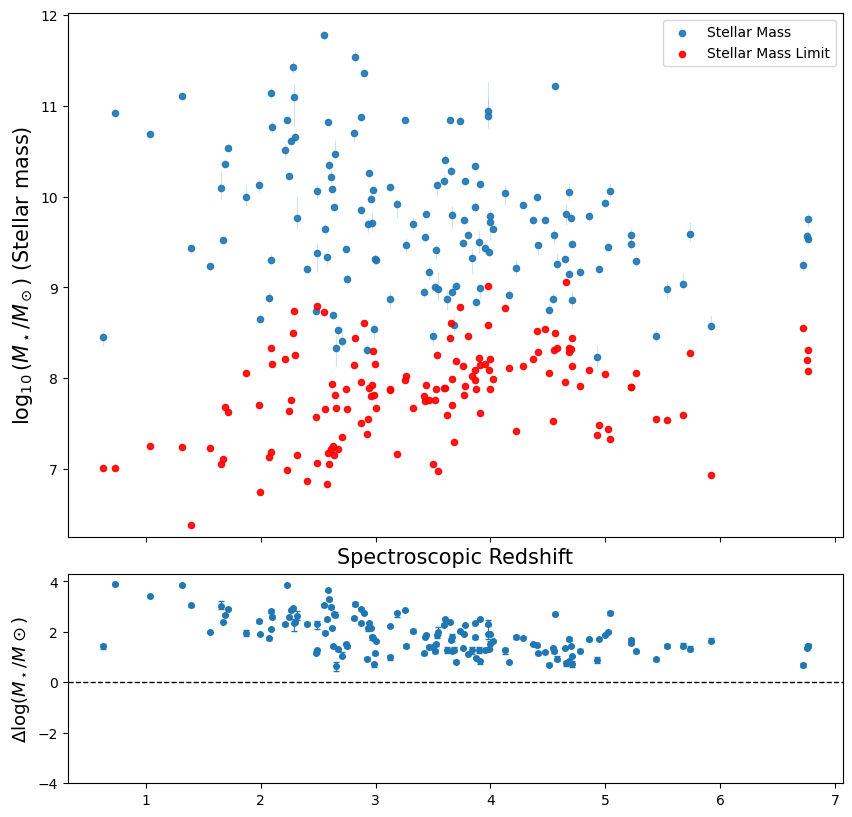

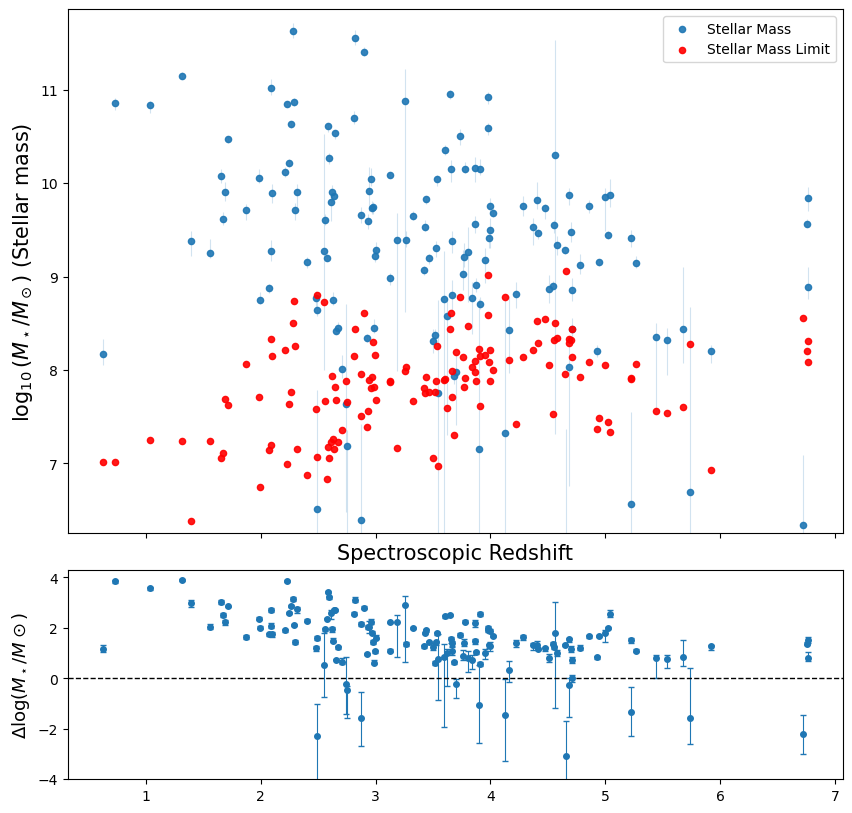

In [27]:
if __name__ == "__main__":

    new_galaxy_table, stellar_only_and_galaxy_table, stellar_AGN_and_galaxy_table = new_tables()

    plot_mass_lims_vs_z(stellar_only_and_galaxy_table)

    plot_mass_lims_vs_z(stellar_AGN_and_galaxy_table)